First of all, set the 'CODE_DIR' to where the model code are saved. This will change current working directory and print for checking. Afterwards, we import all required modules.

In [1]:
import os

# Save the current PATH
original_path = os.environ['PATH']

# Set CUDA 12.5 environment variables, appending the original PATH explicitly
os.environ['CUDA_HOME'] = '/usr/local/cuda-12.5'
os.environ['PATH'] = f"/usr/local/cuda-12.5/bin:{original_path}"
os.environ['LD_LIBRARY_PATH'] = f"/usr/local/cuda-12.5/lib64:{os.environ.get('LD_LIBRARY_PATH', '')}"

#!rm -rf /home/ids/yuhe/.cache/torch_extensions
CODE_DIR = '/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/pSp_encoder_constructive'

import os
os.chdir(f'{CODE_DIR}')

notebook_path = os.getcwd()
print('Current working directory is:', '\n', notebook_path) 

Current working directory is: 
 /home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/pSp_encoder_constructive


In [2]:


from argparse import Namespace
import time
import sys
import pprint
import numpy as np
from PIL import Image
import torch
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from IPython.display import display

sys.path.append(".")
sys.path.append("..")

# from datasets import augmentations
from utils.common import tensor2im, log_input_image
# from models.psp import pSp

from notebooks.def_funcs import load_sparsity_model, load_ema_model, evaluate_model, transform_images_to_batch, load_folder_images, \
    show_latent_map, visulize_singleImg_paired2, visulize_singleImg_paired3, visulize_singleImg_paired4, visulize_singleImg_paired5
# %load_ext autoreload
# %autoreload 2

/home/ids/yuhe/anaconda3/envs/styleGANenv/lib/python3.11/site-packages/torch/utils/cpp_extension.py:2059: UserWarning: TORCH_CUDA_ARCH_LIST is not set, all archs for visible cards are included for compilation. 
If this is not desired, please set os.environ['TORCH_CUDA_ARCH_LIST'].
  warnings.warn(
/home/ids/yuhe/anaconda3/envs/styleGANenv/lib/python3.11/site-packages/torch/utils/cpp_extension.py:2059: UserWarning: TORCH_CUDA_ARCH_LIST is not set, all archs for visible cards are included for compilation. 
If this is not desired, please set os.environ['TORCH_CUDA_ARCH_LIST'].
  warnings.warn(


In [3]:
EXPERIMENT_PARMS = {
        # "model_orn_path": "/home/ids/yuhe/Projects/CA_with_GAN/3_code_styleGAN/pretrained_models/e4e_models/e4e_ffhq_encode.pt",
        #"model1_path": "../results/csmlp_sparsity/mlp3D/nodim/checkpoints/iteration_100000.pt",
        "model1_path": "./results/csmlp_sparsity/mlp3D/nodim/checkpoints/iteration_100000.pt",
        "model2_path": "./results/cmlp_baseline/3Dmlp/checkpoints/iteration_130000.pt",
        "images_bg_path" : "../eval_images/test_bg_imgs/", 
        "images_t_path" : "../eval_images/test_t_imgs/", 
        "model_output_size" : 1024,
        "transform": transforms.Compose([
            transforms.Resize((256, 256)),
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])]) 
}

In [4]:
model1_path = EXPERIMENT_PARMS['model1_path']
model2_path = EXPERIMENT_PARMS['model2_path']
image_bg_paths = EXPERIMENT_PARMS["images_bg_path"]
image_t_paths = EXPERIMENT_PARMS["images_t_path"]

transform = EXPERIMENT_PARMS['transform']
device = 'cuda'


In [5]:
%matplotlib inline
images_bg= load_folder_images(image_bg_paths)
images_t= load_folder_images(image_t_paths)

input_images_bg = transform_images_to_batch(images_bg, transform).to(device).float()
input_images_t = transform_images_to_batch(images_t, transform).to(device).float()

custom_indices = torch.tensor([0, 1, 2, 3])  # Example custom order for batch size of 4
input_images_bg = input_images_bg[custom_indices]
custom_indices = torch.tensor([3, 2, 1, 0])
input_images_t = input_images_t[custom_indices]


RuntimeError: CUDA error: out of memory
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


### Load pretrained pSp model

In [6]:
# def shift_with_avg(codes):
#         # normalize with respect to the center of an average face
#     shifted_codes = codes + pSp_net.latent_avg.repeat(codes.shape[0], 1, 1)
#     return shifted_codes

In [7]:
# pSp_checkpoint_path = '../pretrained_models/pSp_models/psp_ffhq_encode.pt'

# print('Loading pSp from checkpoint: {}'.format(pSp_checkpoint_path))
# ckpt = torch.load(pSp_checkpoint_path, map_location='cpu', weights_only=True)


Loading trained checkpoint from path: results/adversarial_common/1st_alternate/cmlp150_with_cls50ep/lr1e-3/checkpoints/iteration_155000.pt
training_step:  155000
Loading pSp from checkpoint: ../pretrained_models/pSp_models/psp_ffhq_encode.pt
Loading trained checkpoint from path: results/adversarial_common/1st_alternate/cmlp150_with_cls50ep/lr1e-3/checkpoints/iteration_155000.pt


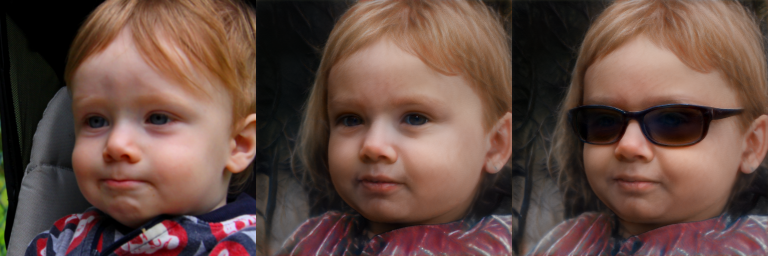

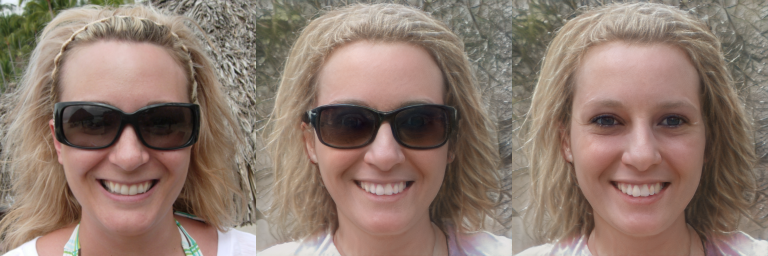

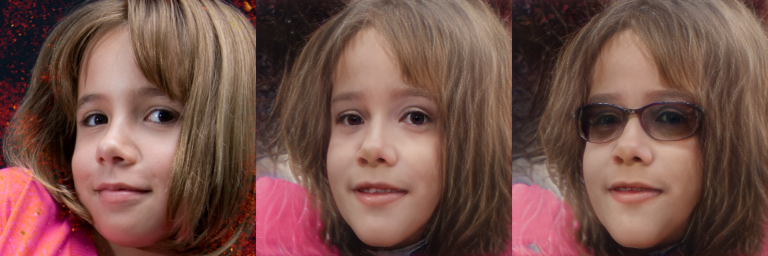

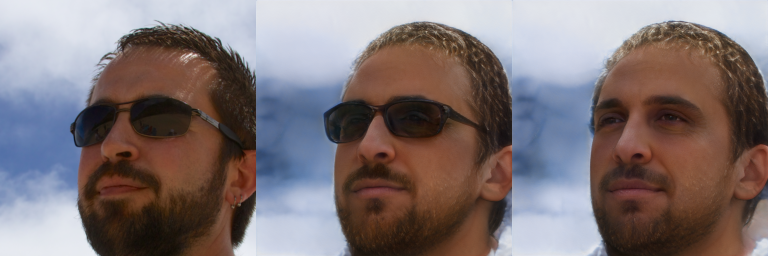

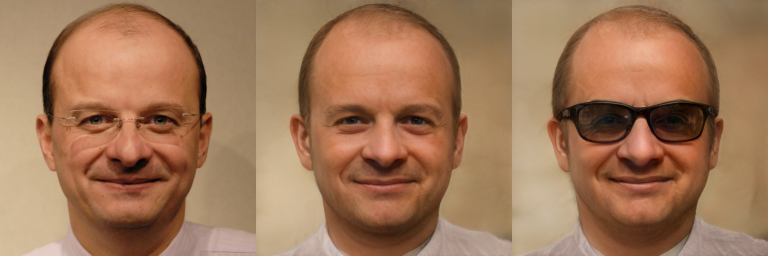

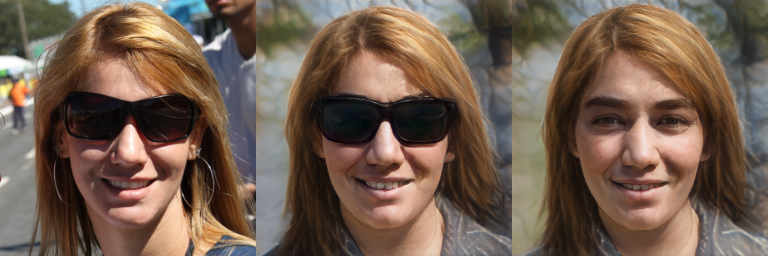

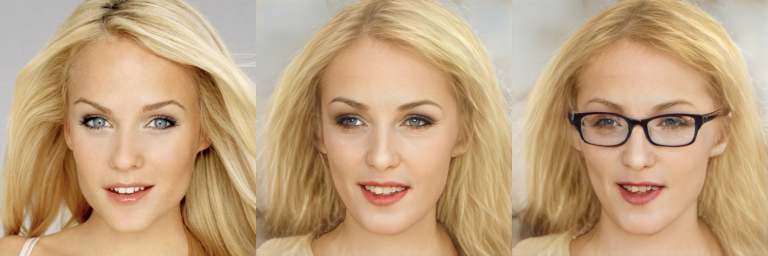

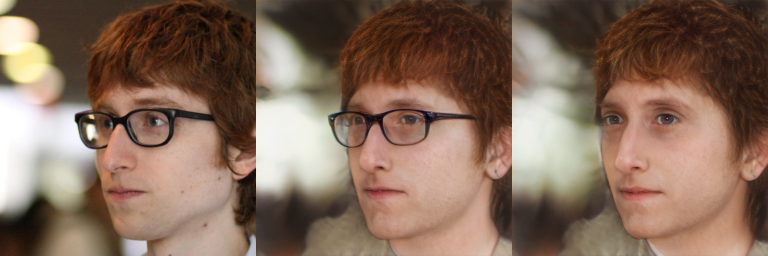

In [10]:
# model1_path = "./results/alternative_cls_131k/checkpoints/iteration_131800.pt"
model1_path = "results/adversarial_common/1st_alternate/cmlp150_with_cls50ep/lr1e-3/checkpoints/iteration_155000.pt"
pSp_net, cs_mlp_net, opts = load_sparsity_model(model1_path, device=device)


with torch.no_grad():
    # rec_x_t_pSp, w_t_pSp = pSp_net.forward(input_images_t, return_latents=True)  
    
    # latent_t_c, latent_t_s = csmlp_net(w_t_pSp, zero_out_silent=opts.zero_out_silent_t)

    # rec_x_t_pSp1 = pSp_net.forward(w_t_pSp, input_code=True, randomize_noise=True, recon_modle=True)
    # rec_x_t = pSp_net.forward(latent_t_c + latent_t_s, input_code=True, randomize_noise=True, recon_modle=True)

    w_pSp_bg = pSp_net.forward(input_images_bg, encode_only=True)  
    w_pSp_t = pSp_net.forward(input_images_t, encode_only=True)  

    latent_bg_c, latent_bg_s = cs_mlp_net(w_pSp_bg, zero_out_silent=opts.zero_out_silent_bg)
    latent_t_c, latent_t_s = cs_mlp_net(w_pSp_t, zero_out_silent=opts.zero_out_silent_t) 

    recon_bg = pSp_net.forward(latent_bg_c, input_code=True, randomize_noise=False, recon_modle=True)
    recon_t = pSp_net.forward(latent_t_c + latent_t_s, input_code=True, randomize_noise=False, recon_modle=True)

    swap_bg = pSp_net.forward(latent_bg_c + latent_t_s, input_code=True, randomize_noise=False, recon_modle=True)
    swap_t = pSp_net.forward(latent_t_c , input_code=True, randomize_noise=False, recon_modle=True)    


# # # visulize_images_batch(recon_t, axis_dim=1)
n_images = input_images_bg.shape[0]

for i in range (n_images):
    visulize_singleImg_paired3(input_images_bg[i,:,:,:], recon_bg[i,:,:,:], swap_bg[i,:,:,:])
    visulize_singleImg_paired3(input_images_t[i,:,:,:], recon_t[i,:,:,:], swap_t[i,:,:,:])

# output_images_1, output_latents_1 = evaluate_model(csmlp_net1, pSp_net1, input_images_bg, input_images_t, opts1)


In [9]:
from training_cls.cls_models import CustomLatentClassifier

import torch
import torch.nn as nn

model_path = "1layer_lr0.0001_bs4/checkpoints/model_epoch_50.pth"
model = load_model(model_path, num_layers=1)  # Change num_layers if needed

# Load the trained model from checkpoint

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize model
model = CustomLatentClassifier(input_dim=18*512, num_layers=1, hidden_dim=None).to(device)
model.to(device)

# Load weights
model.load_state_dict(torch.load(checkpoint_path, map_location=device))
model.eval()  # Set to evaluation mode
print(f"Loaded model from {checkpoint_path}")



ModuleNotFoundError: No module named 'training_cls'